# Bathymetry options

**What this shows:** how the `XBeachBathy` options change the model bathymetry:
depth convention, interpolation, and seaward and lateral extension.

**Prerequisites:** [Tutorial 3: Bathymetry from your data](../tutorial/03_bathymetry.ipynb).

**You will learn:**

- how `posdwn` matches the sign convention of your data
- how the interpolation method and gap filling affect the result
- how the extension slope and target depth set the size of the seaward extension
- how lateral extension widens the domain

**Data used:** `bathy.tif`.

## Setup

`profile()` generates the bathymetry for a given `XBeachBathy` and returns the
cross-shore profile along the middle of the grid, which makes options easy to compare.

In [1]:
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from rompy.logging import config as logging_config
from rompy_xbeach.data.bathy import SeawardExtensionLinear, XBeachBathy
from rompy_xbeach.grid import RegularGrid
from rompy_xbeach.interpolate import RegularGridInterpolator
from rompy_xbeach.source import SourceGeotiff

logging_config.update(level="WARNING")  # rompy logs every step, show warnings only

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "bathymetry_options"
shutil.rmtree(OUT_DIR, ignore_errors=True)
OUT_DIR.mkdir(parents=True)

grid = RegularGrid(
    ori={"x": 115.594239, "y": -32.641104, "crs": 4326},
    alfa=347.0,
    dx=10.0,
    dy=15.0,
    nx=230,
    ny=220,
    crs=28350,
)
source = SourceGeotiff(filename=DATA_DIR / "bathy.tif")


def profile(bathy):
    """Return cross-shore distance and depth along the middle row of the model grid."""
    _, _, depfile, model_grid = bathy.get(destdir=OUT_DIR, grid=grid)
    depth = np.loadtxt(depfile)
    distance = np.arange(model_grid.nx) * model_grid.dx
    return distance, depth[model_grid.ny // 2], model_grid

## 1. Depth convention: `posdwn`

`posdwn` states whether the source values are depths (positive down, the default) or
elevations (positive up). It is passed to XBeach as `posdwn = 1` or `-1`, and the
seaward extension uses it to extend in the right direction. `bathy.tif` holds
elevations, so `posdwn=False`.

In [2]:
for posdwn in (True, False):
    print(f"posdwn={posdwn}: {XBeachBathy(source=source, posdwn=posdwn).params}")

posdwn=True: {'posdwn': 1}
posdwn=False: {'posdwn': -1}


## 2. Interpolation and gaps

`RegularGridInterpolator` passes its `kwargs` to
`scipy.interpolate.RegularGridInterpolator`. Here linear and nearest-neighbour
interpolation are compared. Gaps (NaN) in the source are filled along x and y before
interpolating unless `interpolate_na=False`.

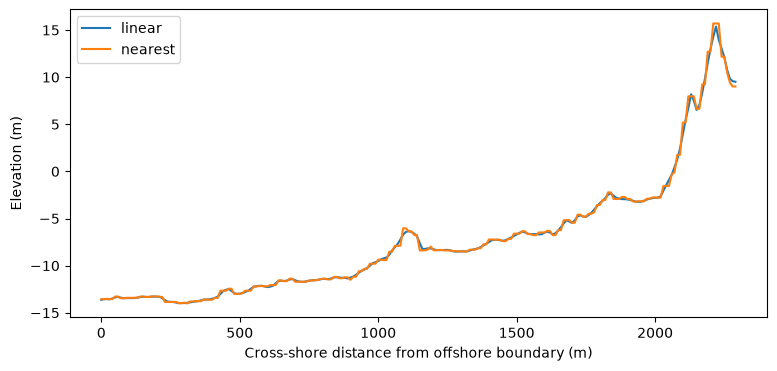

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
for method in ("linear", "nearest"):
    bathy = XBeachBathy(
        source=source,
        posdwn=False,
        interpolator=RegularGridInterpolator(
            kwargs={"method": method, "fill_value": None}
        ),
    )
    distance, depth, _ = profile(bathy)
    ax.plot(distance, depth, label=method)
ax.set(xlabel="Cross-shore distance from offshore boundary (m)", ylabel="Elevation (m)")
ax.legend()
plt.show()

## 3. Seaward extension

`SeawardExtensionLinear` adds cells offshore so the bed slopes linearly from the
offshore edge of the data down to `depth`. A gentler `slope` gives a longer extension.

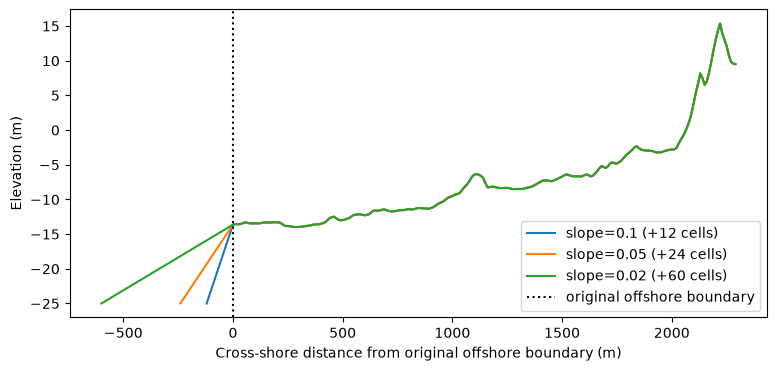

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
for slope in (0.1, 0.05, 0.02):
    bathy = XBeachBathy(
        source=source,
        posdwn=False,
        extension=SeawardExtensionLinear(depth=25.0, slope=slope),
    )
    distance, depth, model_grid = profile(bathy)
    added = model_grid.nx - grid.nx
    ax.plot(distance - added * grid.dx, depth, label=f"slope={slope} (+{added} cells)")
ax.axvline(0, color="k", linestyle=":", label="original offshore boundary")
ax.set(
    xlabel="Cross-shore distance from original offshore boundary (m)",
    ylabel="Elevation (m)",
)
ax.legend()
plt.show()

## 4. Lateral extension

`left` and `right` add grid rows on each side by repeating the edge profiles. This
moves the lateral boundaries, and their artefacts, away from the area of interest.
The two sides can differ.

Original grid: 230 x 220 points
Extended grid: 230 x 245 points


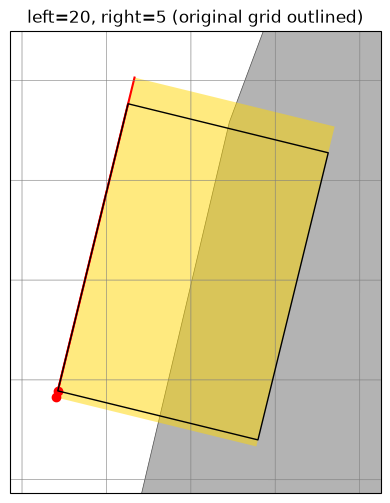

In [5]:
bathy = XBeachBathy(source=source, posdwn=False, left=20, right=5)
_, _, model_grid = profile(bathy)
print(f"Original grid: {grid.nx} x {grid.ny} points")
print(f"Extended grid: {model_grid.nx} x {model_grid.ny} points")

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"projection": grid.projection})
model_grid.plot(
    ax=ax, scale="h", grid_kwargs={"facecolor": "gold", "alpha": 0.5, "zorder": 2}
)
grid.plot(
    ax=ax,
    grid_kwargs={"facecolor": "none", "edgecolor": "black", "zorder": 3},
    set_extent=False,
)
ax.set_title("left=20, right=5 (original grid outlined)")
plt.show()

## Summary

| Option | Default | Effect |
|---|---|---|
| `posdwn` | `True` | Sign convention of the source values |
| `interpolator` | linear | Interpolation onto the grid |
| `interpolate_na` | `True` | Fill gaps in the source before interpolating |
| `extension` | slope 0.3 to 25 m | Offshore extension to a uniform depth |
| `left`, `right` | 0 | Rows added on each lateral side |